In [ ]:
# Реализация методов оптимизации SGD и Adam

# В данной работе исследуются различные методы оптимизации для обучения модели линейной регрессии при решении задачи прогнозирования стоимости квартир.

# Рассматриваются следующие методы:
# SGD (Stochastic Gradient Descent)
# Adam.

# Также исследуется влияние регуляризации:
# L1-регуляризации
# L2-регуляризации.

# Сравнение методов производится по значениям функции ошибки MSE, RMSE и коэффициента детерминации R².

In [57]:
import csv
import random

import matplotlib.pyplot as plt

In [59]:
# Общие функции
def gradient(w, b,   data, number_of_sings=19):
    grad = [0 for i in range(number_of_sings)]#градиент
    gradb = 0#градиент свободного члена
    for i in range(len(data)):
        pred = b
        for j in range(number_of_sings):
            pred += w[j]*data[i][j]
        err = pred - data[i][-1]
        for j in range(number_of_sings):
            grad[j] += err*data[i][j]*2
        gradb += err*2
        #считаем градиент по каждой квартире и складываем потом усредним
    for i in range(number_of_sings):
        grad[i] /= len(data)#усредняем
    gradb /= len(data)
    return grad, gradb#возвращает градиент по перменным и градиент по свободному члену отдельно

def data_normalized(list_dt, mean=None, std=None):
    if mean is None or std is None:#считаем среднее на тренировочных данных
        mean = [0 for i in range(len(list_dt[0])-1)]
        for i in range(len(list_dt)):
            for j in range(len(list_dt[i])-1):
                mean[j] += list_dt[i][j]
        for i in range(len(mean)):
            mean[i] /= len(list_dt)
        std = [0 for i in range(len(mean))]
        for i in range(len(list_dt)):
            for j in range(len(list_dt[i])-1):
                std[j] += (list_dt[i][j] - mean[j])**2
        for i in range(len(std)):
            std[i] /= len(list_dt)
            std[i] = std[i] ** 0.5
    else:#если поданы просто присваеваем без вычислений
        mean = mean
        std = std
    new_list_dt = []
    for i in range(len(list_dt)):
        row_i = []
        for j in range(len(list_dt[i])-1):
            x_i_j = (list_dt[i][j]-mean[j])/std[j]#z-стандартизация превращает данные в числа от -1 до 1
            row_i.append(x_i_j)
        row_i.append(list_dt[i][-1])#добавляем целевую переменную
        new_list_dt.append(row_i)
    return new_list_dt, mean, std

def prev_csv(data):#функция переводит данные в список мне так проще хотя может и неэффективней
    list_data = []
    flag = 0
    for row in data:
        if flag == 0:
            flag+=1
        else:
            l = list(row)
            t = [float(i) for i in l]
            list_data.append(t)
    return list_data

def errors(data, v, b):
    mse = 0
    mn = 0
    for i in range(len(data)):
        pred = b
        for j in range(len(v)):
            pred += v[j] * data[i][j]
        err = data[i][-1] - pred
        mse += err * err
        mn += data[i][-1]
    mse /= len(data)
    rmse = mse ** 0.5

    mn /= len(data)
    ss_total = 0
    ss_res = 0
    for i in range(len(data)):
        pred = b
        for j in range(len(v)):
            pred += v[j] * data[i][j]
        ss_total += (mn - data[i][-1]) ** 2
        ss_res += (data[i][-1] - pred) ** 2

    r = 1 - ss_res / ss_total

    print("mse:", mse)
    print("rmse:", rmse)
    print("r:", r)
    return mse, rmse, r

In [85]:
# Загрузка данных
file = open('dataset_sample_1000.csv', 'r')

train_data = csv.reader(file)

train_list_data = prev_csv(train_data)

file.close()

train_list_data, mean, std = data_normalized(train_list_data)

file = open('dataset_prepared.csv', 'r')

test_data = csv.reader(file)

test_list_data = prev_csv(test_data)

file.close()

test_list_data, mean, std = data_normalized(
    test_list_data,
    mean,
    std
)

In [ ]:
# Реализация стохастического градиентного спуска (SGD)

# Алгоритм SGD отличается от обычного градиентного спуска тем, что обновление весов производится после обработки каждого обучающего примера, а не после вычисления градиента по всему набору данных.

# Это позволяет быстрее сходиться на больших объемах данных и уменьшает затраты памяти.

In [86]:
def find_weight_sgd(
    data,
    number_of_epochs=30,
    learning_rate=0.0005
):

    # количество признаков
    number_of_signs = len(data[0]) - 1

    # веса
    w = [0.0 for _ in range(number_of_signs)]

    # свободный член
    b = sum(row[-1] for row in data) / len(data)

    # история ошибки
    mse_history = []

    for epoch in range(number_of_epochs):

        # перемешиваем данные
        random.shuffle(data)

        # проходим по каждой квартире
        for sample in data:

            # вычисляем градиент по одной квартире
            g, gb = gradient(w, b, [sample], number_of_signs)

            # обновляем веса
            for j in range(number_of_signs):
                w[j] -= learning_rate * g[j]

            # обновляем свободный член
            b -= learning_rate * gb

        # вычисляем MSE после эпохи
        mse, _, _ = errors(data, w, b)
        mse_history.append(mse)

    return w, b, mse_history

mse: 0.08716026728801295
rmse: 0.29522917756890654
r: 0.7287530539945078
mse: 0.06519651453610974
rmse: 0.25533608153982024
r: 0.7971053094676024
mse: 0.06112816917486855
rmse: 0.24724111546194852
r: 0.8097661960030436
mse: 0.06004224756389047
rmse: 0.24503519658181858
r: 0.8131456363116174
mse: 0.05963691080389743
rmse: 0.24420669688585
r: 0.8144070638137677
mse: 0.05948711188320355
rmse: 0.2438997988584729
r: 0.8148732452633823
mse: 0.05937597584924064
rmse: 0.24367186101238822
r: 0.8152191059490089
mse: 0.05929358592821327
rmse: 0.24350274316363105
r: 0.8154755073478993
mse: 0.05928751579911637
rmse: 0.2434902786542337
r: 0.815494397881747
mse: 0.059270877063936696
rmse: 0.24345610911196436
r: 0.8155461784262921
mse: 0.05918322448497946
rmse: 0.24327602529838294
r: 0.8158189574699029
mse: 0.05915512171486566
rmse: 0.24321825941911857
r: 0.8159064146428192
mse: 0.059151578440996735
rmse: 0.24321097516558898
r: 0.8159174414816037
mse: 0.05909266624901836
rmse: 0.24308983164463782
r: 0

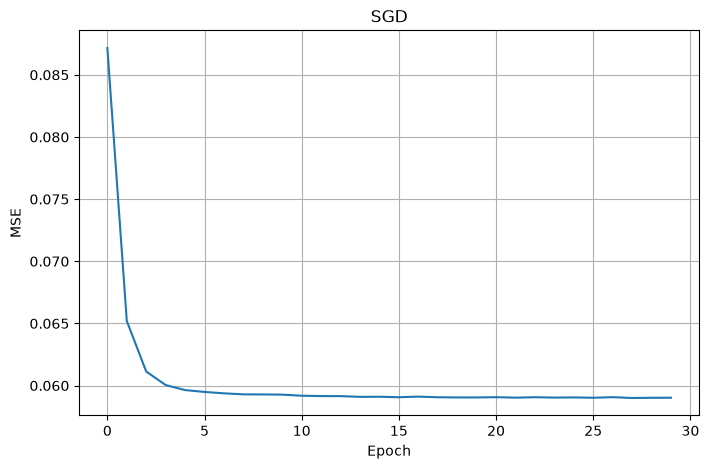

In [87]:
w_sgd, b_sgd, mse_history = find_weight_sgd(
    train_list_data,
    number_of_epochs=30,
    learning_rate=0.0005
)
mse_test, rmse_test, r_test = errors(
    test_list_data,
    w_sgd,
    b_sgd
)
plt.figure(figsize=(8,5))

plt.plot(mse_history)

plt.xlabel("Epoch")

plt.ylabel("MSE")

plt.title("SGD")

plt.grid(True)

plt.show()

In [ ]:
# При learning rate = 0.01 алгоритм демонстрировал нестабильную сходимость. После уменьшения шага до 0.0005 процесс обучения стал устойчивым, а значение функции потерь начало монотонно уменьшаться.

In [ ]:
# SGD с L2-регуляризацией

# Для борьбы с переобучением используется L2-регуляризация.

# К функции потерь добавляется штраф за большие значения весов:

# L = MSE + λ Σ(wᵢ²)

# Параметр λ определяет силу регуляризации. Чем больше λ, тем сильнее модель стремится уменьшать веса.
#То есть к градиенту добавляется: 2 * lambda_ * w[j]

In [88]:
#Код SGD + L2

def find_weight_sgd_l2(
    data,
    number_of_epochs=30,
    learning_rate=0.0005,
    lambda_=0.01
):

    number_of_signs = len(data[0]) - 1

    w = [0.0 for _ in range(number_of_signs)]

    b = sum(row[-1] for row in data) / len(data)

    mse_history = []

    for epoch in range(number_of_epochs):

        random.shuffle(data)

        for sample in data:

            g, gb = gradient(w, b, [sample], number_of_signs)

            for j in range(number_of_signs):

                w[j] -= learning_rate * (
                    g[j] + 2 * lambda_ * w[j]
                )

            b -= learning_rate * gb

        mse, _, _ = errors(data, w, b)
        mse_history.append(mse)

    return w, b, mse_history

mse: 0.08670690820281851
rmse: 0.29446036779644646
r: 0.7301639292835485
mse: 0.06500654347460115
rmse: 0.254963808166181
r: 0.7976965085525398
mse: 0.06100408770680965
rmse: 0.24699005588648634
r: 0.810152343502519
mse: 0.05998472311208289
rmse: 0.24491778847622092
r: 0.8133246551737545
mse: 0.05964639638179451
rmse: 0.24422611732121222
r: 0.8143775442389006
mse: 0.059454462914212865
rmse: 0.2438328585613778
r: 0.8149748504259697
mse: 0.059461193631805985
rmse: 0.2438466600792514
r: 0.814953904108934
mse: 0.05934548316727592
rmse: 0.24360928382817418
r: 0.8153140006426092
mse: 0.059242266076358574
rmse: 0.24339734196650253
r: 0.8156352171964137
mse: 0.05925154241090373
rmse: 0.24341639716934382
r: 0.8156063487969264
mse: 0.05922115562111883
rmse: 0.24335397186222135
r: 0.8157009139489677
mse: 0.05916039460007842
rmse: 0.243229098999438
r: 0.8158900051703029
mse: 0.059132103359926955
rmse: 0.24317093444720517
r: 0.8159780488710459
mse: 0.05912244116996874
rmse: 0.243151066561446
r: 0.8

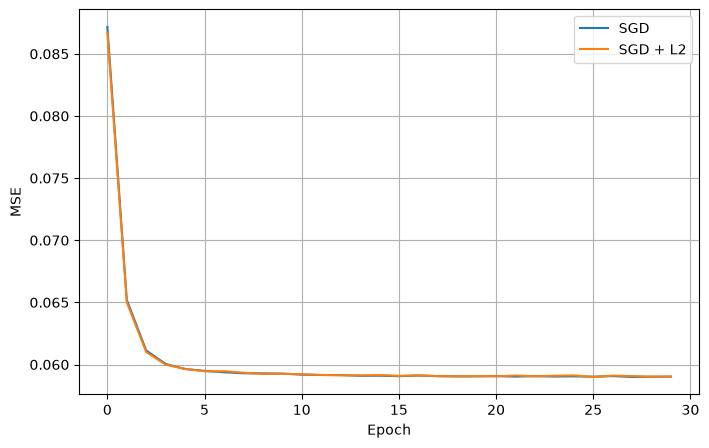

In [89]:
w_l2, b_l2, mse_l2 = find_weight_sgd_l2(
    train_list_data,
    learning_rate=0.0005,
    lambda_=0.001
)

plt.figure(figsize=(8,5))

plt.plot(mse_history, label="SGD")

plt.plot(mse_l2, label="SGD + L2")

plt.xlabel("Epoch")
plt.ylabel("MSE")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# Вывод по L2-регуляризации

# После добавления L2-регуляризации существенных изменений в процессе обучения не наблюдалось. График изменения функции потерь практически совпадает с графиком обычного SGD, а качество модели изменилось незначительно.

# Это можно объяснить тем, что выбранное значение параметра регуляризации λ оказалось небольшим, поэтому влияние штрафа на веса модели было слабым. Тем не менее использование L2-регуляризации позволяет ограничивать рост коэффициентов модели и снижает вероятность переобучения при обучении на больших наборах данных.

In [ ]:
# SGD с L1-регуляризацией

# L1-регуляризация также используется для борьбы с переобучением, однако в отличие от L2 она добавляет штраф, пропорциональный сумме модулей весов модели.

# Функция потерь принимает вид:
# L = MSE + λ Σ|wᵢ|

# L1-регуляризация способствует занулению некоторых коэффициентов модели, благодаря чему происходит автоматический отбор наиболее значимых признаков.

In [65]:
# Код SGD + L1

def find_weight_sgd_l1(
    data,
    number_of_epochs=30,
    learning_rate=0.0005,
    lambda_=0.001
):

    number_of_signs = len(data[0]) - 1

    w = [0.0 for _ in range(number_of_signs)]

    b = sum(row[-1] for row in data) / len(data)

    mse_history = []

    for epoch in range(number_of_epochs):

        random.shuffle(data)

        for sample in data:

            g, gb = gradient(w, b, [sample], number_of_signs)

            for j in range(number_of_signs):

                # знак веса
                if w[j] > 0:
                    reg = lambda_
                elif w[j] < 0:
                    reg = -lambda_
                else:
                    reg = 0

                w[j] -= learning_rate * (g[j] + reg)

            b -= learning_rate * gb

        mse, _, _ = errors(data, w, b)
        mse_history.append(mse)

    return w, b, mse_history

mse: 0.08630847754822578
rmse: 0.2937830450319177
r: 0.731403864653367
mse: 0.06490697117162744
rmse: 0.2547684658108759
r: 0.7980063823508742
mse: 0.06103159639690347
rmse: 0.24704573745949043
r: 0.8100667351352122
mse: 0.06008337496998466
rmse: 0.24511910364144338
r: 0.8130176458447762
mse: 0.05965816185583844
rmse: 0.2442502033895539
r: 0.8143409295175138
mse: 0.059498684341839886
rmse: 0.24392352150180163
r: 0.8148372312152325
mse: 0.05940728190953085
rmse: 0.2437360906996148
r: 0.8151216799829192
mse: 0.05941619595734283
rmse: 0.24375437628346866
r: 0.8150939390371785
mse: 0.05927086156643199
rmse: 0.24345607728383367
r: 0.8155462266552729
mse: 0.05924122078971109
rmse: 0.24339519467259638
r: 0.8156384701787602
mse: 0.059234157637183316
rmse: 0.2433806846016818
r: 0.81566045104931
mse: 0.05920596384573454
rmse: 0.24332275653077445
r: 0.8157481914850013
mse: 0.05924740286768996
rmse: 0.2434078940126839
r: 0.8156192312546046
mse: 0.05913735003100793
rmse: 0.24318172223875695
r: 0.81

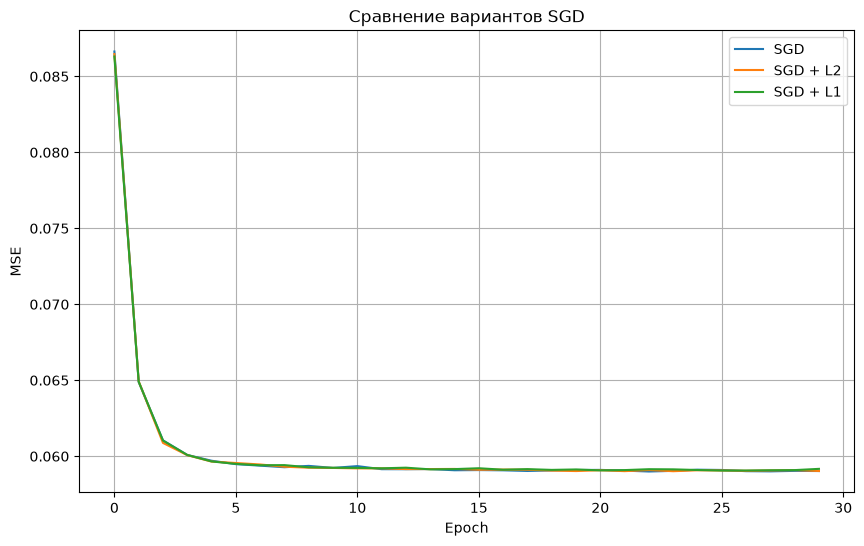

In [66]:
w_l1, b_l1, mse_l1 = find_weight_sgd_l1(
    train_list_data,
    learning_rate=0.0005,
    lambda_=0.001
)
errors(
    test_list_data,
    w_l1,
    b_l1
)
plt.figure(figsize=(10,6))

plt.plot(mse_history, label="SGD")

plt.plot(mse_l2, label="SGD + L2")

plt.plot(mse_l1, label="SGD + L1")

plt.xlabel("Epoch")

plt.ylabel("MSE")

plt.title("Сравнение вариантов SGD")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# Вывод

# Добавление L1-регуляризации также не привело к существенному изменению поведения алгоритма при выбранном значении параметра λ. Процесс обучения оставался стабильным, а значения функции потерь были близки к результатам обычного SGD.

In [ ]:
# Общий вывод по SGD

# В ходе работы были реализованы три варианта стохастического градиентного спуска:

# классический SGD;
# SGD с L2-регуляризацией;
# SGD с L1-регуляризацией.

# Во всех случаях алгоритм успешно сходился при правильно подобранном значении скорости обучения. Наиболее существенное влияние на стабильность обучения оказал параметр learning rate. При слишком большом значении наблюдались колебания функции потерь, тогда как уменьшение шага обучения обеспечило устойчивую сходимость.

# Использование L1- и L2-регуляризации при выбранных значениях λ не оказало значительного влияния на качество модели. Однако данные методы являются важными инструментами борьбы с переобучением и могут давать заметный эффект при обучении на более сложных выборках или при других значениях параметра регуляризации.

In [ ]:
# Реализация метода Adam

# В отличие от обычного SGD, Adam автоматически подбирает шаг обучения для каждого параметра модели отдельно.

# Алгоритм использует две оценки:
# первый момент (среднее значение градиента);
# второй момент (среднее значение квадрата градиента).

# Это позволяет сделать обучение более стабильным и ускорить сходимость модели.

In [67]:
# Код метода Adam

import math

def find_weight_adam(
    data,
    number_of_epochs=30,
    learning_rate=0.0005,
    beta1=0.9,
    beta2=0.999,
    epsilon=1e-8
):

    number_of_signs = len(data[0]) - 1

    w = [0.0 for _ in range(number_of_signs)]
    b = sum(row[-1] for row in data) / len(data)

    # первый момент
    m = [0.0 for _ in range(number_of_signs)]

    # второй момент
    v = [0.0 for _ in range(number_of_signs)]

    # для свободного члена
    m_b = 0.0
    v_b = 0.0

    mse_history = []

    t = 0

    for epoch in range(number_of_epochs):

        random.shuffle(data)

        for sample in data:

            t += 1

            g, gb = gradient(w, b, [sample], number_of_signs)

            for j in range(number_of_signs):

                # первый момент
                m[j] = beta1 * m[j] + (1 - beta1) * g[j]

                # второй момент
                v[j] = beta2 * v[j] + (1 - beta2) * (g[j] ** 2)

                # коррекция смещения
                m_hat = m[j] / (1 - beta1 ** t)
                v_hat = v[j] / (1 - beta2 ** t)

                # обновление веса
                w[j] -= learning_rate * m_hat / (math.sqrt(v_hat) + epsilon)

            # свободный член

            m_b = beta1 * m_b + (1 - beta1) * gb
            v_b = beta2 * v_b + (1 - beta2) * (gb ** 2)

            m_hat_b = m_b / (1 - beta1 ** t)
            v_hat_b = v_b / (1 - beta2 ** t)

            b -= learning_rate * m_hat_b / (math.sqrt(v_hat_b) + epsilon)

        mse, _, _ = errors(data, w, b)
        mse_history.append(mse)

    return w, b, mse_history

mse: 0.11159645654845754
rmse: 0.3340605582053313
r: 0.6527064571316806
mse: 0.07212657601214598
rmse: 0.2685639142032041
r: 0.7755386246753949
mse: 0.06163200935094228
rmse: 0.24825794922004465
r: 0.808198221130006
mse: 0.059599941982143474
rmse: 0.2441309934894451
r: 0.8145221125660281
mse: 0.05962682879662066
rmse: 0.24418605364889426
r: 0.8144384395055657
mse: 0.05932192036610343
rmse: 0.24356091715647532
r: 0.8153873292137145
mse: 0.05945064229033668
rmse: 0.2438250239215341
r: 0.8149867403913232
mse: 0.0593382908635118
rmse: 0.24359452141522353
r: 0.8153363834380217
mse: 0.05930665464120134
rmse: 0.2435295765224449
r: 0.815434836884206
mse: 0.05916561824891973
rmse: 0.2432398368872166
r: 0.8158737489237435
mse: 0.05923700150025607
rmse: 0.24338652694891735
r: 0.8156516008105792
mse: 0.059498354387858166
rmse: 0.24392284515366364
r: 0.8148382580479012
mse: 0.05964025226399637
rmse: 0.24421353824879646
r: 0.8143966650291468
mse: 0.05923491250700357
rmse: 0.24338223539733456
r: 0.81

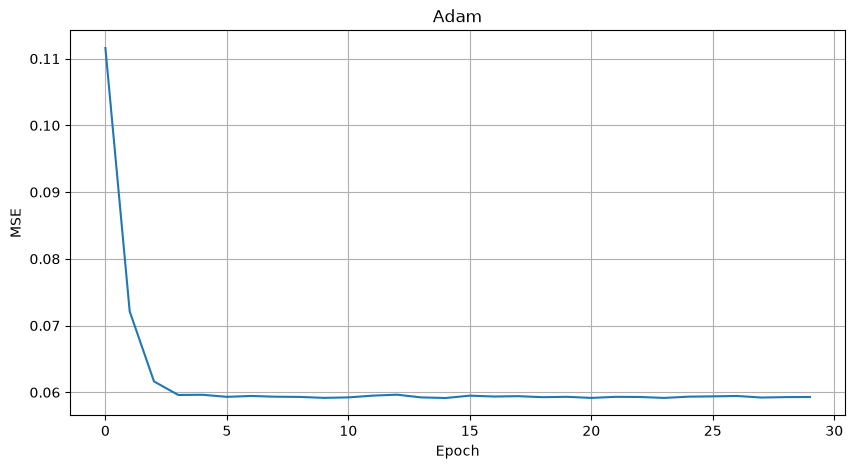

In [68]:
w_adam, b_adam, mse_adam = find_weight_adam(
    train_list_data
)
errors(
    test_list_data,
    w_adam,
    b_adam
)
plt.figure(figsize=(10,5))

plt.plot(mse_adam)

plt.xlabel("Epoch")

plt.ylabel("MSE")

plt.title("Adam")

plt.grid()

plt.show()

In [69]:
# Adam с L2-регуляризацией

# В этом случае обновление весов производится с учетом дополнительного штрафа, пропорционального квадрату величины каждого коэффициента модели.

In [70]:
# Реализация Adam + L2

def find_weight_adam_l2(
    data,
    number_of_epochs=30,
    learning_rate=0.0005,
    beta1=0.9,
    beta2=0.999,
    epsilon=1e-8,
    lambda_=0.01
):

    number_of_signs = len(data[0]) - 1

    w = [0.0 for _ in range(number_of_signs)]
    b = sum(row[-1] for row in data) / len(data)

    m = [0.0 for _ in range(number_of_signs)]
    v = [0.0 for _ in range(number_of_signs)]

    m_b = 0.0
    v_b = 0.0

    mse_history = []

    t = 0

    for epoch in range(number_of_epochs):

        random.shuffle(data)

        for sample in data:

            t += 1

            g, gb = gradient(w, b, [sample], number_of_signs)

            for j in range(number_of_signs):

                m[j] = beta1 * m[j] + (1 - beta1) * g[j]
                v[j] = beta2 * v[j] + (1 - beta2) * g[j] ** 2

                m_hat = m[j] / (1 - beta1 ** t)
                v_hat = v[j] / (1 - beta2 ** t)

                w[j] -= learning_rate * (
                    m_hat / (math.sqrt(v_hat) + epsilon)
                    + 2 * lambda_ * w[j]
                )

            m_b = beta1 * m_b + (1 - beta1) * gb
            v_b = beta2 * v_b + (1 - beta2) * gb ** 2

            m_hat_b = m_b / (1 - beta1 ** t)
            v_hat_b = v_b / (1 - beta2 ** t)

            b -= learning_rate * m_hat_b / (math.sqrt(v_hat_b) + epsilon)

        mse, _, _ = errors(data, w, b)
        mse_history.append(mse)

    return w, b, mse_history

mse: 0.11892454273308423
rmse: 0.34485437902553046
r: 0.6299011002931476
mse: 0.07224174769166575
rmse: 0.26877825003460704
r: 0.7751802048665974
mse: 0.061618488734762826
rmse: 0.24823071674303893
r: 0.8082402979381766
mse: 0.05976240050045151
rmse: 0.2444634952307839
r: 0.8140165338394507
mse: 0.0596198478996654
rmse: 0.2441717590133335
r: 0.8144601643928151
mse: 0.05944553518019129
rmse: 0.2438145507966891
r: 0.815002633963853
mse: 0.059942505117820684
rmse: 0.24483158521281662
r: 0.8134560396034537
mse: 0.059725428483579486
rmse: 0.24438786484516675
r: 0.8141315925350724
mse: 0.05936944470438309
rmse: 0.24365845912749076
r: 0.8152394311860881
mse: 0.05930703708371321
rmse: 0.24353036172870357
r: 0.8154336467047056
mse: 0.0595365843887007
rmse: 0.2440011975148907
r: 0.8147192844456281
mse: 0.05955676580183665
rmse: 0.24404254916271598
r: 0.8146564789168071
mse: 0.059290992572445814
rmse: 0.24349741799954638
r: 0.8154835779958414
mse: 0.05943737628784773
rmse: 0.2437978184640866
r: 0

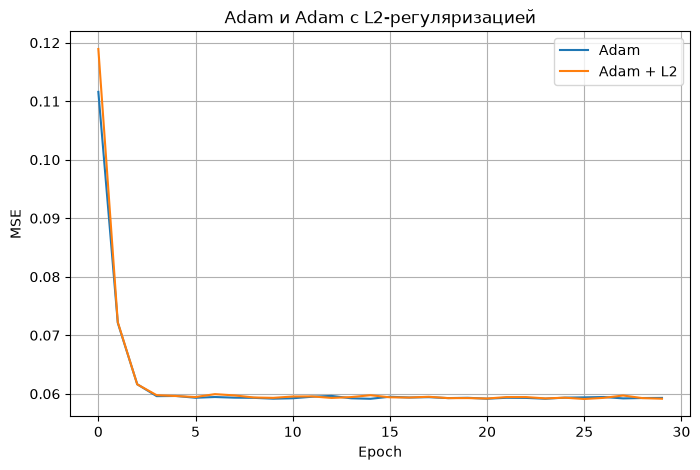

In [71]:
w_adam_l2, b_adam_l2, mse_adam_l2 = find_weight_adam_l2(
    train_list_data,
    lambda_=0.0005
)
errors(
    test_list_data,
    w_adam_l2,
    b_adam_l2
)
plt.figure(figsize=(8,5))

plt.plot(mse_adam, label="Adam")

plt.plot(mse_adam_l2, label="Adam + L2")

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Adam и Adam с L2-регуляризацией")

plt.grid(True)
plt.legend()

plt.show()

In [ ]:
# Вывод

# Добавление L2-регуляризации практически не изменило характер сходимости алгоритма Adam. Графики изменения функции потерь имеют схожую форму, а итоговые значения ошибки отличаются незначительно, хотя график Adam+L2 ведет себя более стабильно. Использование L2 позволяет ограничивать рост коэффициентов модели и снижать вероятность переобучения.

In [ ]:
# Adam с L1-регуляризацией

# L1-регуляризация добавляет к функции потерь сумму модулей коэффициентов модели.

# В отличие от L2-регуляризации, данный метод способен уменьшать отдельные веса до нулевых значений, тем самым автоматически выполняя отбор наиболее значимых признаков.

In [72]:
# Реализация Adam + L1

def find_weight_adam_l1(
    data,
    number_of_epochs=30,
    learning_rate=0.0005,
    beta1=0.9,
    beta2=0.999,
    epsilon=1e-8,
    lambda_=0.001
):

    number_of_signs = len(data[0]) - 1

    # Веса модели
    w = [0.0 for _ in range(number_of_signs)]
    b = sum(row[-1] for row in data) / len(data)

    # Первый момент
    m = [0.0 for _ in range(number_of_signs)]

    # Второй момент
    v = [0.0 for _ in range(number_of_signs)]

    # Для свободного члена
    m_b = 0.0
    v_b = 0.0

    mse_history = []

    t = 0

    for epoch in range(number_of_epochs):

        random.shuffle(data)

        for sample in data:

            t += 1

            g, gb = gradient(w, b, [sample], number_of_signs)

            for j in range(number_of_signs):

                # Первый момент
                m[j] = beta1 * m[j] + (1 - beta1) * g[j]

                # Второй момент
                v[j] = beta2 * v[j] + (1 - beta2) * (g[j] ** 2)

                # Коррекция смещения
                m_hat = m[j] / (1 - beta1 ** t)
                v_hat = v[j] / (1 - beta2 ** t)

                # L1-регуляризация
                if w[j] > 0:
                    reg = lambda_
                elif w[j] < 0:
                    reg = -lambda_
                else:
                    reg = 0

                # Обновление веса
                w[j] -= learning_rate * (
                    m_hat / (math.sqrt(v_hat) + epsilon)
                    + reg
                )

            # Обновление свободного члена

            m_b = beta1 * m_b + (1 - beta1) * gb
            v_b = beta2 * v_b + (1 - beta2) * (gb ** 2)

            m_hat_b = m_b / (1 - beta1 ** t)
            v_hat_b = v_b / (1 - beta2 ** t)

            b -= learning_rate * (
                m_hat_b / (math.sqrt(v_hat_b) + epsilon)
            )

        mse, _, _ = errors(data, w, b)
        mse_history.append(mse)

    return w, b, mse_history

mse: 0.12601010947142374
rmse: 0.3549790268049984
r: 0.6078504756416434
mse: 0.07577194784506286
rmse: 0.2752670482369128
r: 0.7641940521138427
mse: 0.06243933210634314
rmse: 0.24987863475364025
r: 0.8056857938663351
mse: 0.060759354991849125
rmse: 0.24649412770256643
r: 0.8109139634881632
mse: 0.05971304306394493
rmse: 0.2443625238532802
r: 0.8141701365569695
mse: 0.05960085501943519
rmse: 0.24413286345642857
r: 0.8145192711500406
mse: 0.060361444784166385
rmse: 0.2456856625531217
r: 0.8121522792021539
mse: 0.059269461911508226
rmse: 0.24345320271359797
r: 0.8155505824487478
mse: 0.059645369493811246
rmse: 0.24422401498176063
r: 0.8143807399637187
mse: 0.05957977293427011
rmse: 0.24408968215446983
r: 0.814584879613557
mse: 0.05950860271831482
rmse: 0.24394385156899284
r: 0.8148063647503643
mse: 0.05964286385737776
rmse: 0.24421888513662854
r: 0.8143885376248725
mse: 0.05933792945245454
rmse: 0.24359377958489525
r: 0.815337508166623
mse: 0.059271669833839
rmse: 0.2434577372642714
r: 0.

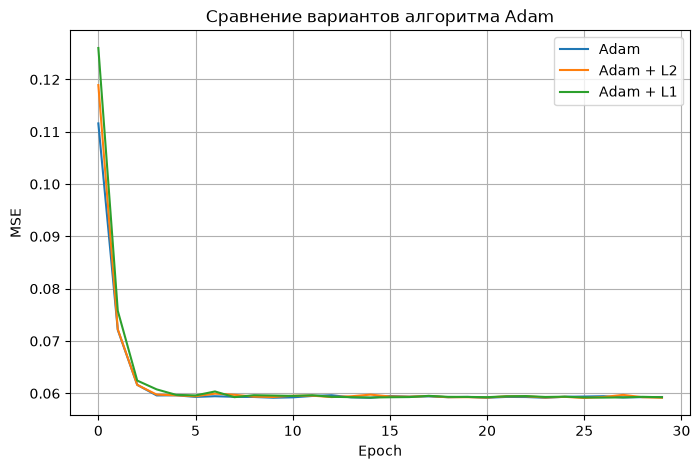

In [73]:
w_adam_l1, b_adam_l1, mse_adam_l1 = find_weight_adam_l1(
    train_list_data,
    lambda_=0.0005
)
errors(
    test_list_data,
    w_adam_l1,
    b_adam_l1
)
plt.figure(figsize=(8,5))

plt.plot(mse_adam, label="Adam")

plt.plot(mse_adam_l2, label="Adam + L2")

plt.plot(mse_adam_l1, label="Adam + L1")

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Сравнение вариантов алгоритма Adam")

plt.grid(True)
plt.legend()

plt.show()

In [ ]:
# Вывод

# Добавление L1-регуляризации также не оказало существенного влияния на скорость сходимости алгоритма Adam при выбранном значении λ. Поведение функции потерь осталось практически таким же, как у базового алгоритма.

In [ ]:
# Общий вывод по Adam

# В ходе работы были реализованы три варианта алгоритма Adam:
# Adam;
# Adam с L2-регуляризацией;
# Adam с L1-регуляризацией.

# Во всех проведённых экспериментах алгоритм Adam продемонстрировал устойчивую сходимость и плавное уменьшение функции потерь. Добавление L1- и L2-регуляризации не оказало существенного влияния на качество модели при выбранных значениях параметра λ, однако данные методы позволяют уменьшить риск переобучения и могут давать более заметный эффект при обучении на более сложных наборах данных.

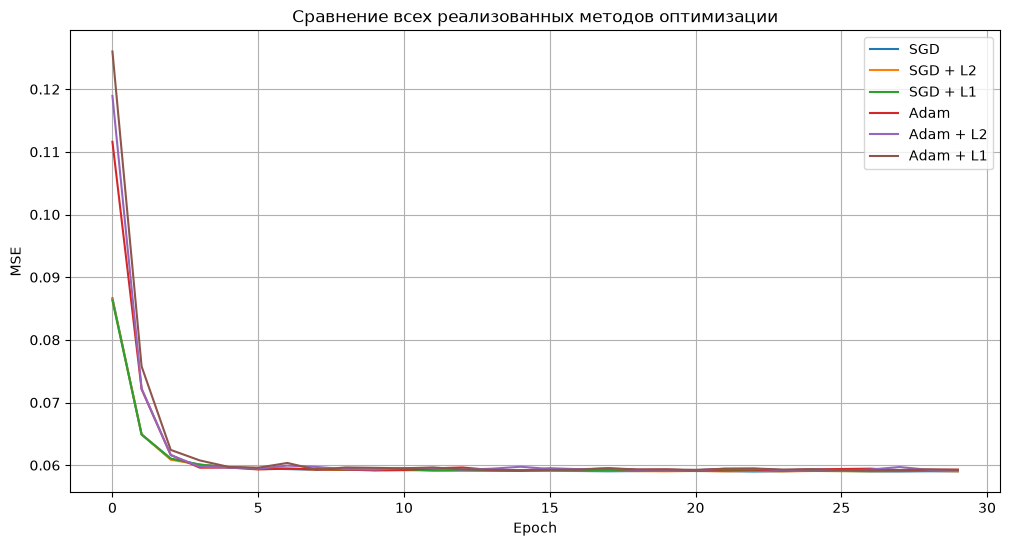

In [74]:
# Результат

plt.figure(figsize=(12,6))

plt.plot(mse_history, label="SGD")

plt.plot(mse_l2, label="SGD + L2")

plt.plot(mse_l1, label="SGD + L1")

plt.plot(mse_adam, label="Adam")

plt.plot(mse_adam_l2, label="Adam + L2")

plt.plot(mse_adam_l1, label="Adam + L1")

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Сравнение всех реализованных методов оптимизации")

plt.grid(True)
plt.legend()

plt.show()

In [75]:
# SGD
mse_sgd, rmse_sgd, r2_sgd = errors(test_list_data, w_sgd, b_sgd)

# SGD + L2
mse_sgd_l2, rmse_sgd_l2, r2_sgd_l2 = errors(test_list_data, w_l2, b_l2)

# SGD + L1
mse_sgd_l1, rmse_sgd_l1, r2_sgd_l1 = errors(test_list_data, w_l1, b_l1)

# Adam
mse_adam_res, rmse_adam_res, r2_adam = errors(test_list_data, w_adam, b_adam)

# Adam + L2
mse_adam_l2_res, rmse_adam_l2_res, r2_adam_l2 = errors(test_list_data, w_adam_l2, b_adam_l2)

# Adam + L1
mse_adam_l1_res, rmse_adam_l1_res, r2_adam_l1 = errors(test_list_data, w_adam_l1, b_adam_l1)

import pandas as pd

results = pd.DataFrame({
    "Метод": [
        "SGD",
        "SGD + L2",
        "SGD + L1",
        "Adam",
        "Adam + L2",
        "Adam + L1"
    ],

    "MSE": [
        mse_sgd,
        mse_sgd_l2,
        mse_sgd_l1,
        mse_adam_res,
        mse_adam_l2_res,
        mse_adam_l1_res
    ],

    "RMSE": [
        rmse_sgd,
        rmse_sgd_l2,
        rmse_sgd_l1,
        rmse_adam_res,
        rmse_adam_l2_res,
        rmse_adam_l1_res
    ],

    "R²": [
        r2_sgd,
        r2_sgd_l2,
        r2_sgd_l1,
        r2_adam,
        r2_adam_l2,
        r2_adam_l1
    ]
})

results = results.round(5)

results


mse: 0.07670095756305949
rmse: 0.276949377257035
r: 0.7654964919663325
mse: 0.07644197196375829
rmse: 0.2764814134146422
r: 0.7662883077857947
mse: 0.07681436434643633
rmse: 0.2771540444345641
r: 0.7651497650233889
mse: 0.07725124818072049
rmse: 0.2779410876080046
r: 0.7638140477781563
mse: 0.07600675346456044
rmse: 0.27569322346506897
r: 0.7676189334789504
mse: 0.07650557124577727
rmse: 0.2765964049762348
r: 0.7660938609990045


,Метод,MSE,RMSE,R²
0,SGD,0.07670,0.27695,0.76550
1,SGD + L2,0.07644,0.27648,0.76629
2,SGD + L1,0.07681,0.27715,0.76515
3,Adam,0.07725,0.27794,0.76381
4,Adam + L2,0.07601,0.27569,0.76762
5,Adam + L1,0.07651,0.27660,0.76609


In [78]:
best = results.loc[results["MSE"].idxmin()]

print(f"Лучший метод: {best['Метод']}")
print(f"MSE = {best['MSE']}")
print(f"RMSE = {best['RMSE']}")
print(f"R² = {best['R²']}")

Лучший метод: Adam + L2
MSE = 0.07601
RMSE = 0.27569
R² = 0.76762


In [ ]:
# Итоговое сравнение методов

# В результате проведённых экспериментов были сравнены шесть вариантов алгоритмов оптимизации:

# SGD;
# SGD с L2-регуляризацией;
# SGD с L1-регуляризацией;
# Adam;
# Adam с L2-регуляризацией;
# Adam с L1-регуляризацией.

# Сравнение проводилось по следующим метрикам качества:

# MSE (Mean Squared Error)** - среднеквадратичная ошибка;
# RMSE (Root Mean Squared Error)** - корень из среднеквадратичной ошибки;
# R² (коэффициент детерминации)** - показывает, насколько хорошо модель объясняет данные.

# На основании полученных результатов можно определить наиболее эффективный алгоритм для рассматриваемого набора данных и оценить влияние регуляризации на качество модели.